In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## **1. Load and inspect the dataset**

In [64]:
df = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\European Credit Card Fraud\creditcard.csv"
)
TARGET = "Class"

In [65]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [66]:
df.sample(5, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,"41,505.0000",-16.5265,8.5850,-18.6499,9.5056,-13.7938,-2.8324,-16.7017,7.5173,-8.5071,-14.1102,5.2992,-10.8340,1.6711,-9.3739,0.3608,-9.8992,-19.2363,-8.3986,3.1017,-1.5149,1.1907,-1.1277,-2.3586,0.6735,-1.4137,-0.4628,-2.0186,-1.0428,364.1900,1
49906,"44,261.0000",0.3398,-2.7437,-0.1341,-1.3857,-1.4514,1.0159,-0.5244,0.2241,0.8997,-0.5650,-0.0877,0.9794,0.0769,-0.2179,-0.1368,-2.1429,0.1270,1.7527,0.4325,0.5060,-0.2134,-0.9425,-0.5268,-1.1570,0.3112,-0.7466,0.0410,0.1020,520.1200,0
29474,"35,484.0000",1.3996,-0.5907,0.1686,-1.0300,-0.5398,0.0404,-0.7126,0.0023,-0.9717,0.7568,0.5438,0.1125,1.0754,-0.2458,0.1805,1.7699,-0.5332,-0.5333,1.1922,0.2129,0.1024,0.1683,-0.1666,-0.8102,0.5051,-0.2323,0.0114,0.0046,31.0000,0
276481,"167,123.0000",-0.4321,1.6479,-1.6694,-0.3495,0.7858,-0.6306,0.2770,0.5860,-0.4847,-1.3766,-1.3283,0.2236,1.1326,-0.5509,0.6166,0.4980,0.5022,0.9813,0.1013,-0.2446,0.3589,0.8737,-0.1786,-0.0172,-0.2074,-0.1578,-0.2374,0.0019,1.5000,0
278846,"168,473.0000",2.0142,-0.1374,-1.0158,0.3273,-0.1822,-0.9566,0.0432,-0.1607,0.3632,0.2595,0.9422,0.8500,-0.6162,0.5926,-0.6038,0.0911,-0.4719,-0.3338,0.4047,-0.2553,-0.2386,-0.6164,0.3470,0.0616,-0.3602,0.1747,-0.0780,-0.0706,0.8900,0


In [67]:
df.shape

(284807, 31)

## **2. Dataset quality and structure**

In [68]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(4),
    "unique_values": df.nunique(),
    "constant_column": df.nunique() <= 1,
}).sort_values("missing_count", ascending=False)

In [69]:
display(quality)

,dtype,missing_count,missing_percent,unique_values,constant_column
Time,float64,0,0.0000,124592,False
V1,float64,0,0.0000,275663,False
V2,float64,0,0.0000,275663,False
V3,float64,0,0.0000,275663,False
V4,float64,0,0.0000,275663,False
V5,float64,0,0.0000,275663,False
V6,float64,0,0.0000,275663,False
V7,float64,0,0.0000,275663,False
V8,float64,0,0.0000,275663,False
V9,float64,0,0.0000,275663,False


In [70]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate percentage: {df.duplicated().mean() * 100:.4f}%")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Duplicate rows: 1,081
Duplicate percentage: 0.3796%
Memory usage: 67.36 MB


## **3. Target distribution and class imbalance**

In [71]:
class_summary = (
    df[TARGET]
    .value_counts()
    .rename_axis("Class")
    .to_frame("count")
)

In [72]:
class_summary["percentage"] = (
    class_summary["count"] / len(df) * 100
).round(6)

class_summary["label"] = class_summary.index.map({
    0: "Legitimate",
    1: "Fraud",
})

display(class_summary)

,count,percentage,label
Class,,,
0,284315,99.8273,Legitimate
1,492,0.1727,Fraud


Fraud rate: 0.172749%
Legitimate-to-fraud ratio: 577.88:1


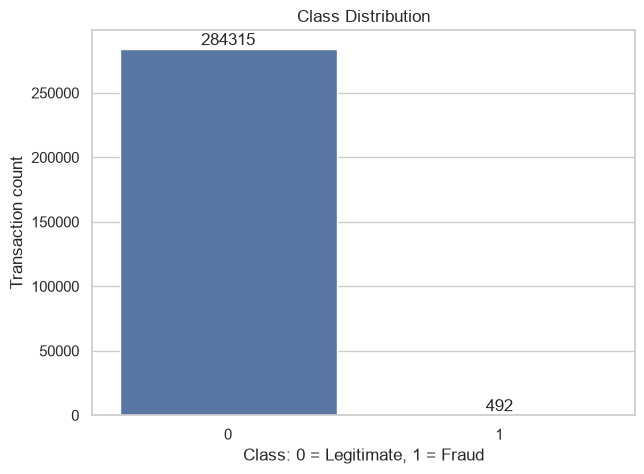

In [73]:
fraud_rate = df[TARGET].mean()
imbalance_ratio = (
    (df[TARGET] == 0).sum() / max((df[TARGET] == 1).sum(), 1)
)

print(f"Fraud rate: {fraud_rate * 100:.6f}%")
print(f"Legitimate-to-fraud ratio: {imbalance_ratio:.2f}:1")

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=TARGET)
ax.set_title("Class Distribution")
ax.set_xlabel("Class: 0 = Legitimate, 1 = Fraud")
ax.set_ylabel("Transaction count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## **4. Descriptive statistics**

In [74]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [75]:
# Statistics separately for legitimate and fraudulent transactions
class_statistics = df.groupby(TARGET).agg(["mean", "median", "std", "min", "max"]).T
display(class_statistics)

Class                    0            1
Time   mean    94,838.2023  80,746.8069
       median  84,711.0000  75,568.5000
       std     47,484.0158  47,835.3651
       min          0.0000     406.0000
       max    172,792.0000 170,348.0000
...                    ...          ...
Amount mean        88.2910     122.2113
       median      22.0000       9.2500
       std        250.1051     256.6833
       min          0.0000       0.0000
       max     25,691.1600   2,125.8700

[150 rows x 2 columns]

## **5. Time and amount analysis**

Time range: 0 to 172,792 seconds
Approximate duration: 2.00 days


,count,min,max,mean,median
Class,,,,,
0,284315,0.0000,"172,792.0000","94,838.2000","84,711.0000"
1,492,406.0000,"170,348.0000","80,746.8100","75,568.5000"


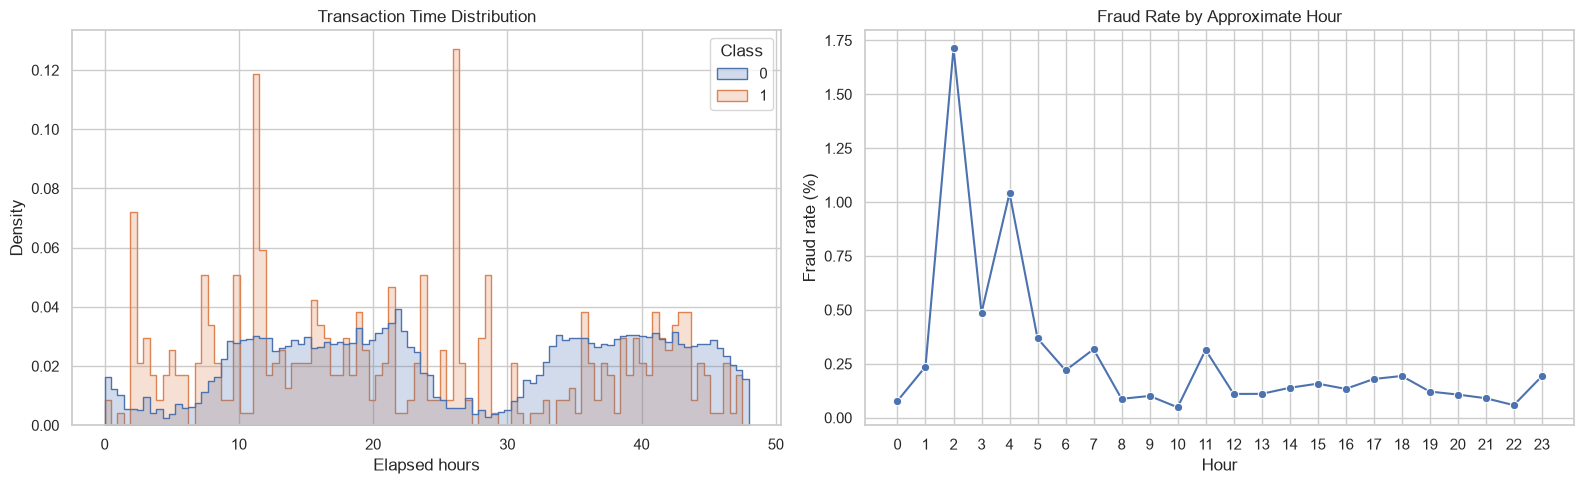

In [76]:
if "Time" in df.columns:
    # Time is elapsed seconds from the first transaction
    time_view = df.copy()
    time_view["Hours"] = time_view["Time"] / 3600
    time_view["Days"] = time_view["Time"] / 86400
    time_view["Hour_of_day_proxy"] = (time_view["Time"] // 3600) % 24
    time_view["Day_index"] = (time_view["Time"] // 86400).astype(int)

    print(f"Time range: {df['Time'].min():,.0f} to {df['Time'].max():,.0f} seconds")
    print(f"Approximate duration: {df['Time'].max() / 86400:.2f} days")

    display(
        time_view.groupby(TARGET)["Time"]
        .agg(["count", "min", "max", "mean", "median"])
        .round(2)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(
        data=time_view,
        x="Hours",
        hue=TARGET,
        bins=100,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title("Transaction Time Distribution")
    axes[0].set_xlabel("Elapsed hours")

    hourly = (
        time_view.groupby("Hour_of_day_proxy")[TARGET]
        .agg(transactions="count", fraud_count="sum", fraud_rate="mean")
        .reset_index()
    )
    hourly["fraud_rate_percent"] = hourly["fraud_rate"] * 100

    sns.lineplot(
        data=hourly,
        x="Hour_of_day_proxy",
        y="fraud_rate_percent",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title("Fraud Rate by Approximate Hour")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Fraud rate (%)")
    axes[1].set_xticks(range(24))

    plt.tight_layout()
    plt.show()

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.2910,22.0000,250.1051,0.0000,"25,691.1600"
1,492,122.2113,9.2500,256.6833,0.0000,"2,125.8700"


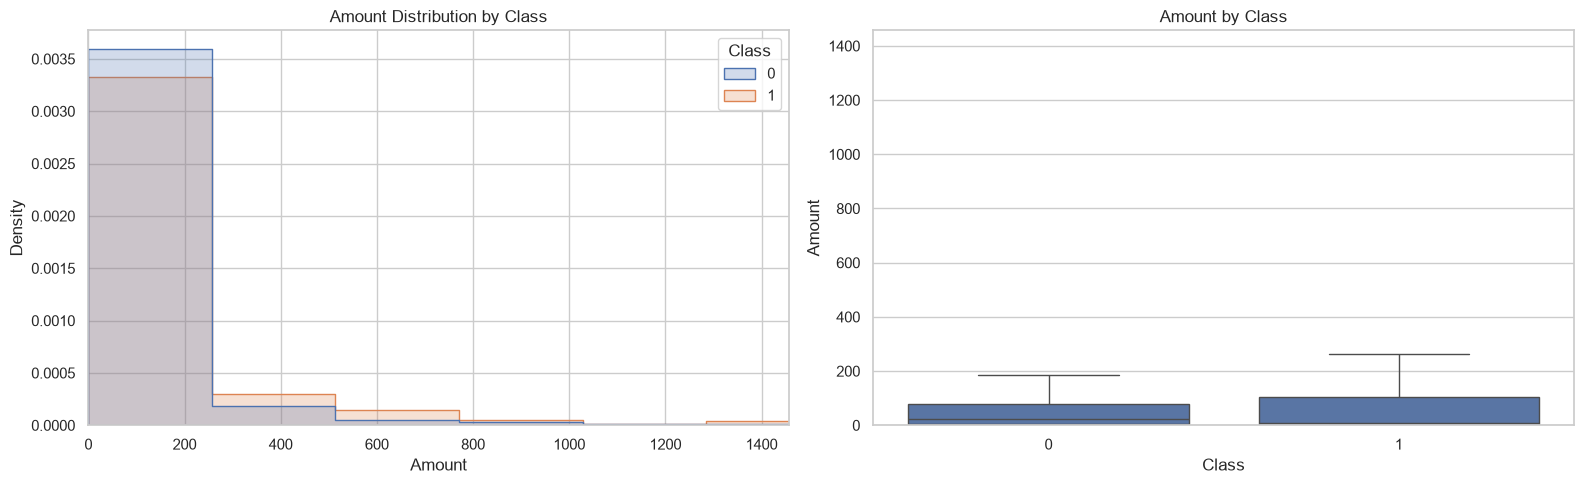

In [77]:
if "Amount" in df.columns:
    display(
        df.groupby(TARGET)["Amount"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(4)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(
        data=df,
        x="Amount",
        hue=TARGET,
        bins=100,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title("Amount Distribution by Class")
    axes[0].set_xlim(0, df["Amount"].quantile(0.995))

    sns.boxplot(
        data=df,
        x=TARGET,
        y="Amount",
        showfliers=False,
        ax=axes[1],
    )
    axes[1].set_title("Amount by Class")
    axes[1].set_ylim(0, df["Amount"].quantile(0.995))

    plt.tight_layout()
    plt.show()

## **6. Fraud rate across amount ranges**

,Amount,transactions,fraud_count,fraud_rate,fraud_rate_percent
0,"(-0.001, 1.0]",30492,181,0.0059,0.5936
1,"(1.0, 3.57]",26473,27,0.0010,0.1020
2,"(3.57, 8.91]",28559,36,0.0013,0.1261
3,"(8.91, 13.0]",28405,13,0.0005,0.0458
4,"(13.0, 22.0]",28714,14,0.0005,0.0488
5,"(22.0, 37.0]",28375,17,0.0006,0.0599
6,"(37.0, 59.8]",28366,24,0.0008,0.0846
7,"(59.8, 100.0]",28915,50,0.0017,0.1729
8,"(100.0, 203.0]",28050,45,0.0016,0.1604
9,"(203.0, 25691.16]",28458,85,0.0030,0.2987


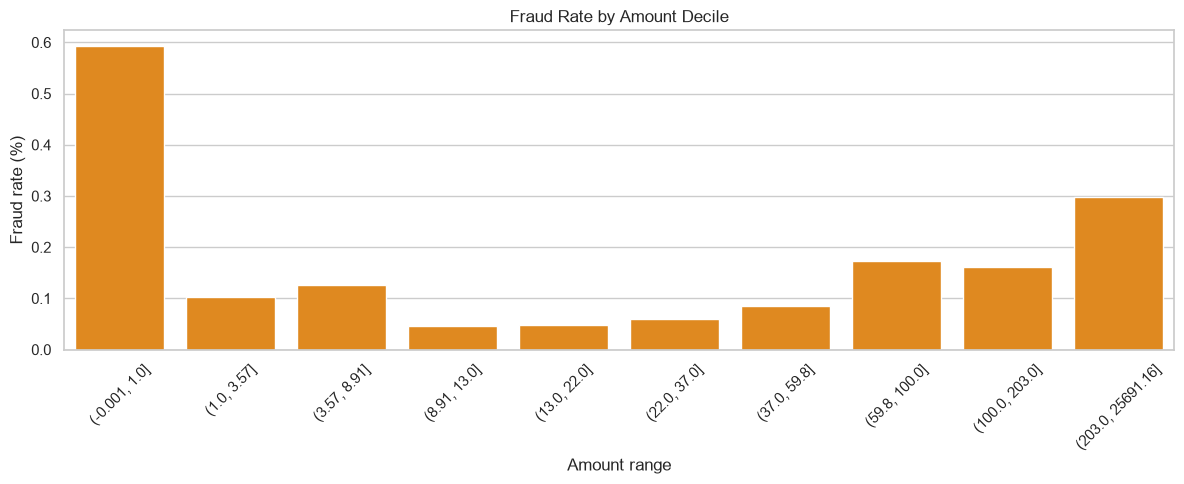

In [78]:
if "Amount" in df.columns:
    amount_bins = pd.qcut(
        df["Amount"],
        q=10,
        duplicates="drop",
    )

    amount_risk = (
        df.groupby(amount_bins, observed=True)[TARGET]
        .agg(
            transactions="count",
            fraud_count="sum",
            fraud_rate="mean",
        )
        .reset_index()
    )

    amount_risk["fraud_rate_percent"] = amount_risk["fraud_rate"] * 100
    display(amount_risk)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=amount_risk,
        x="Amount",
        y="fraud_rate_percent",
        color="darkorange",
    )
    plt.title("Fraud Rate by Amount Decile")
    plt.xlabel("Amount range")
    plt.ylabel("Fraud rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **7. Feature distributions by class**

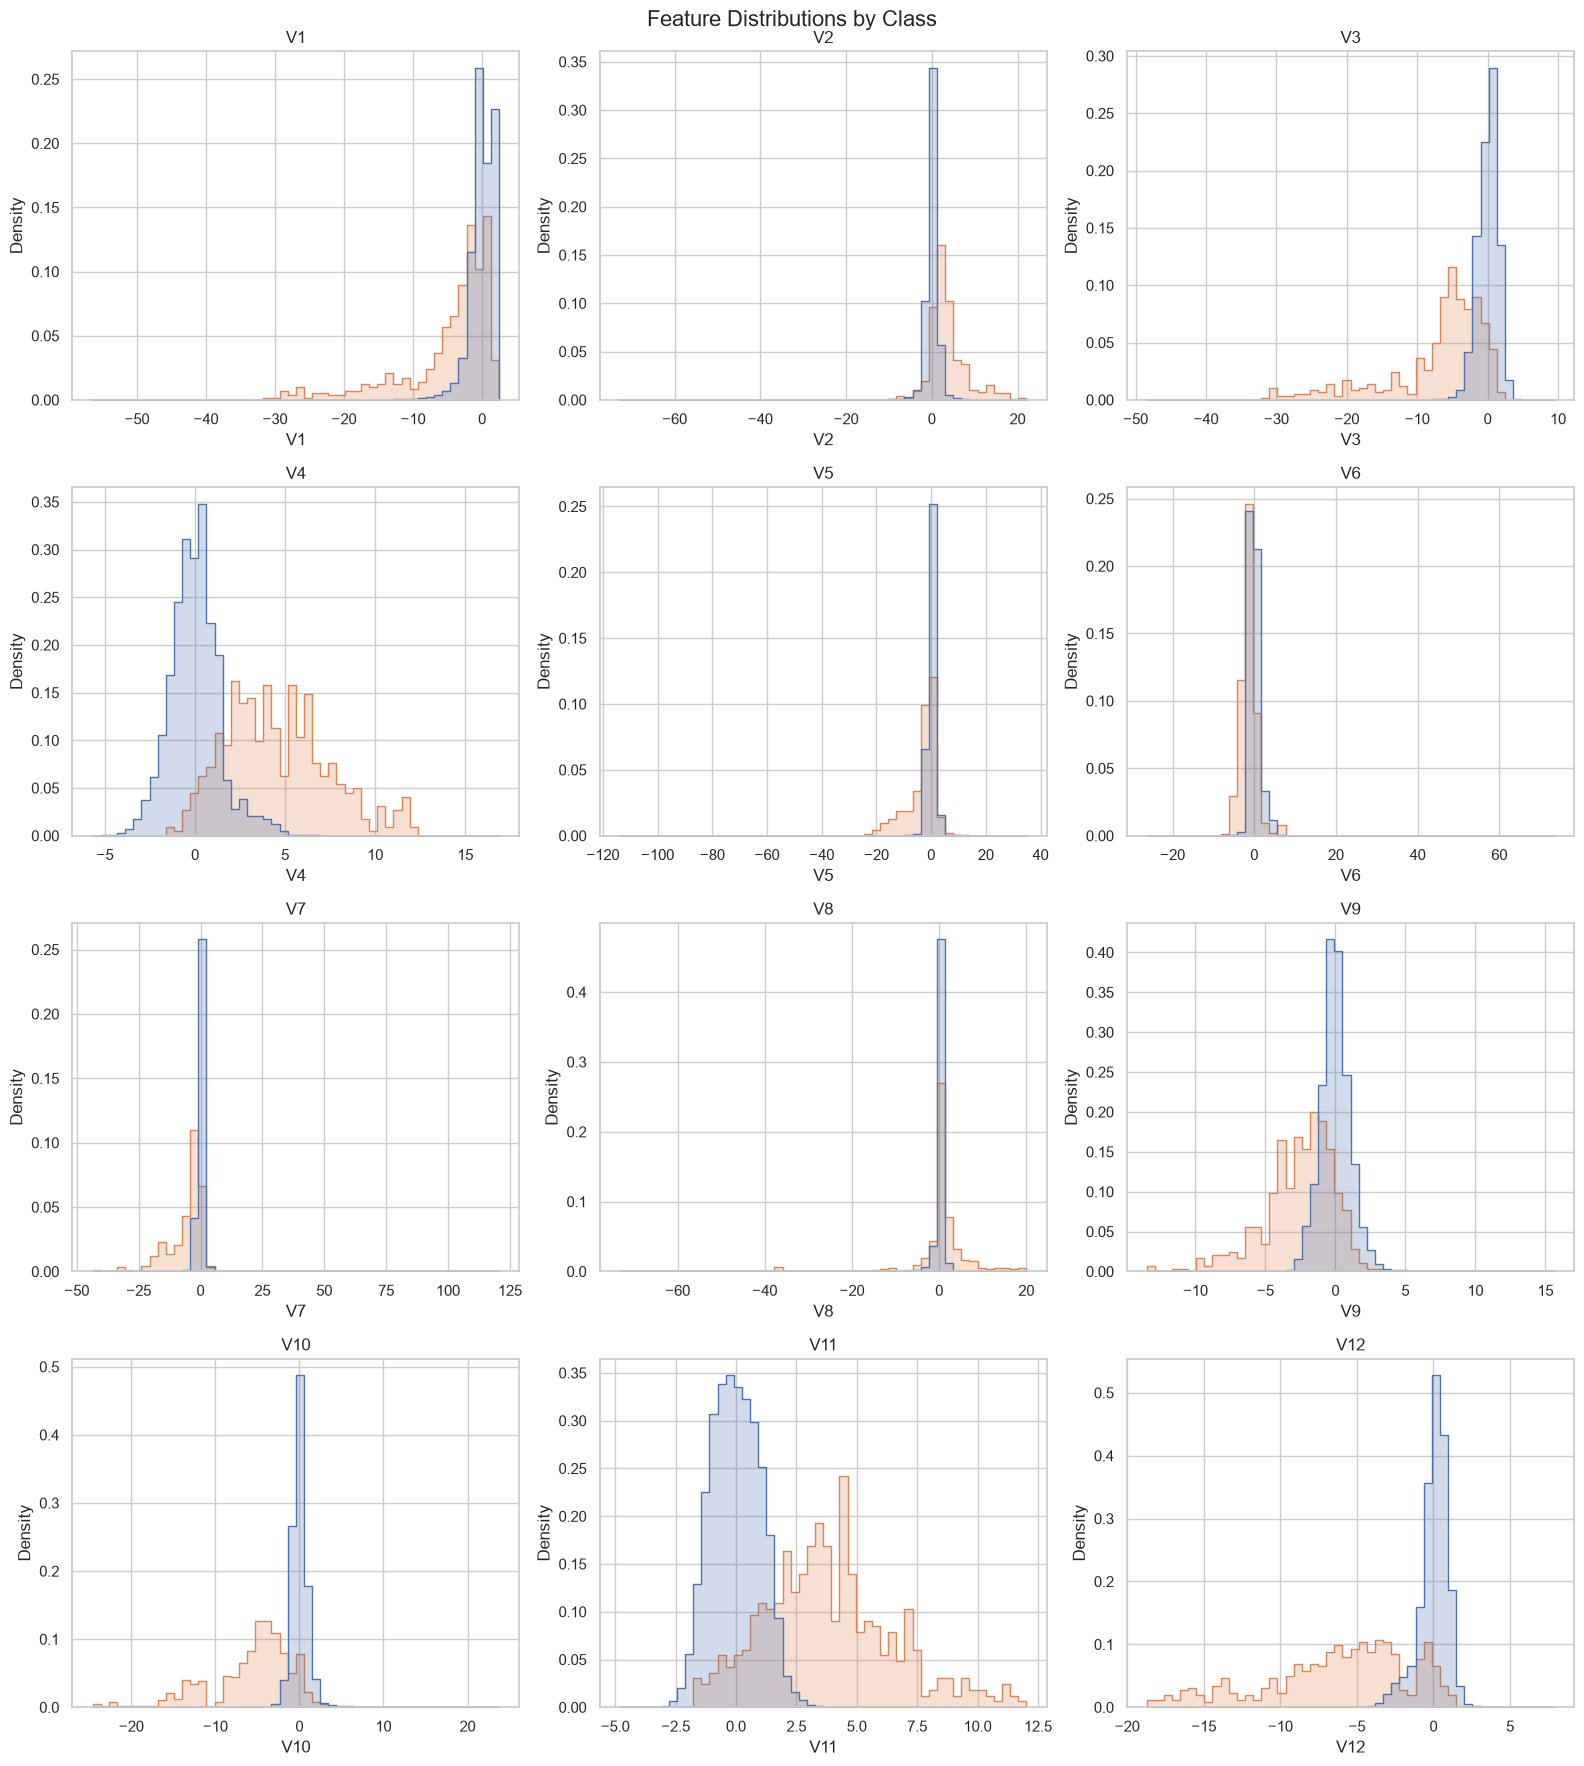

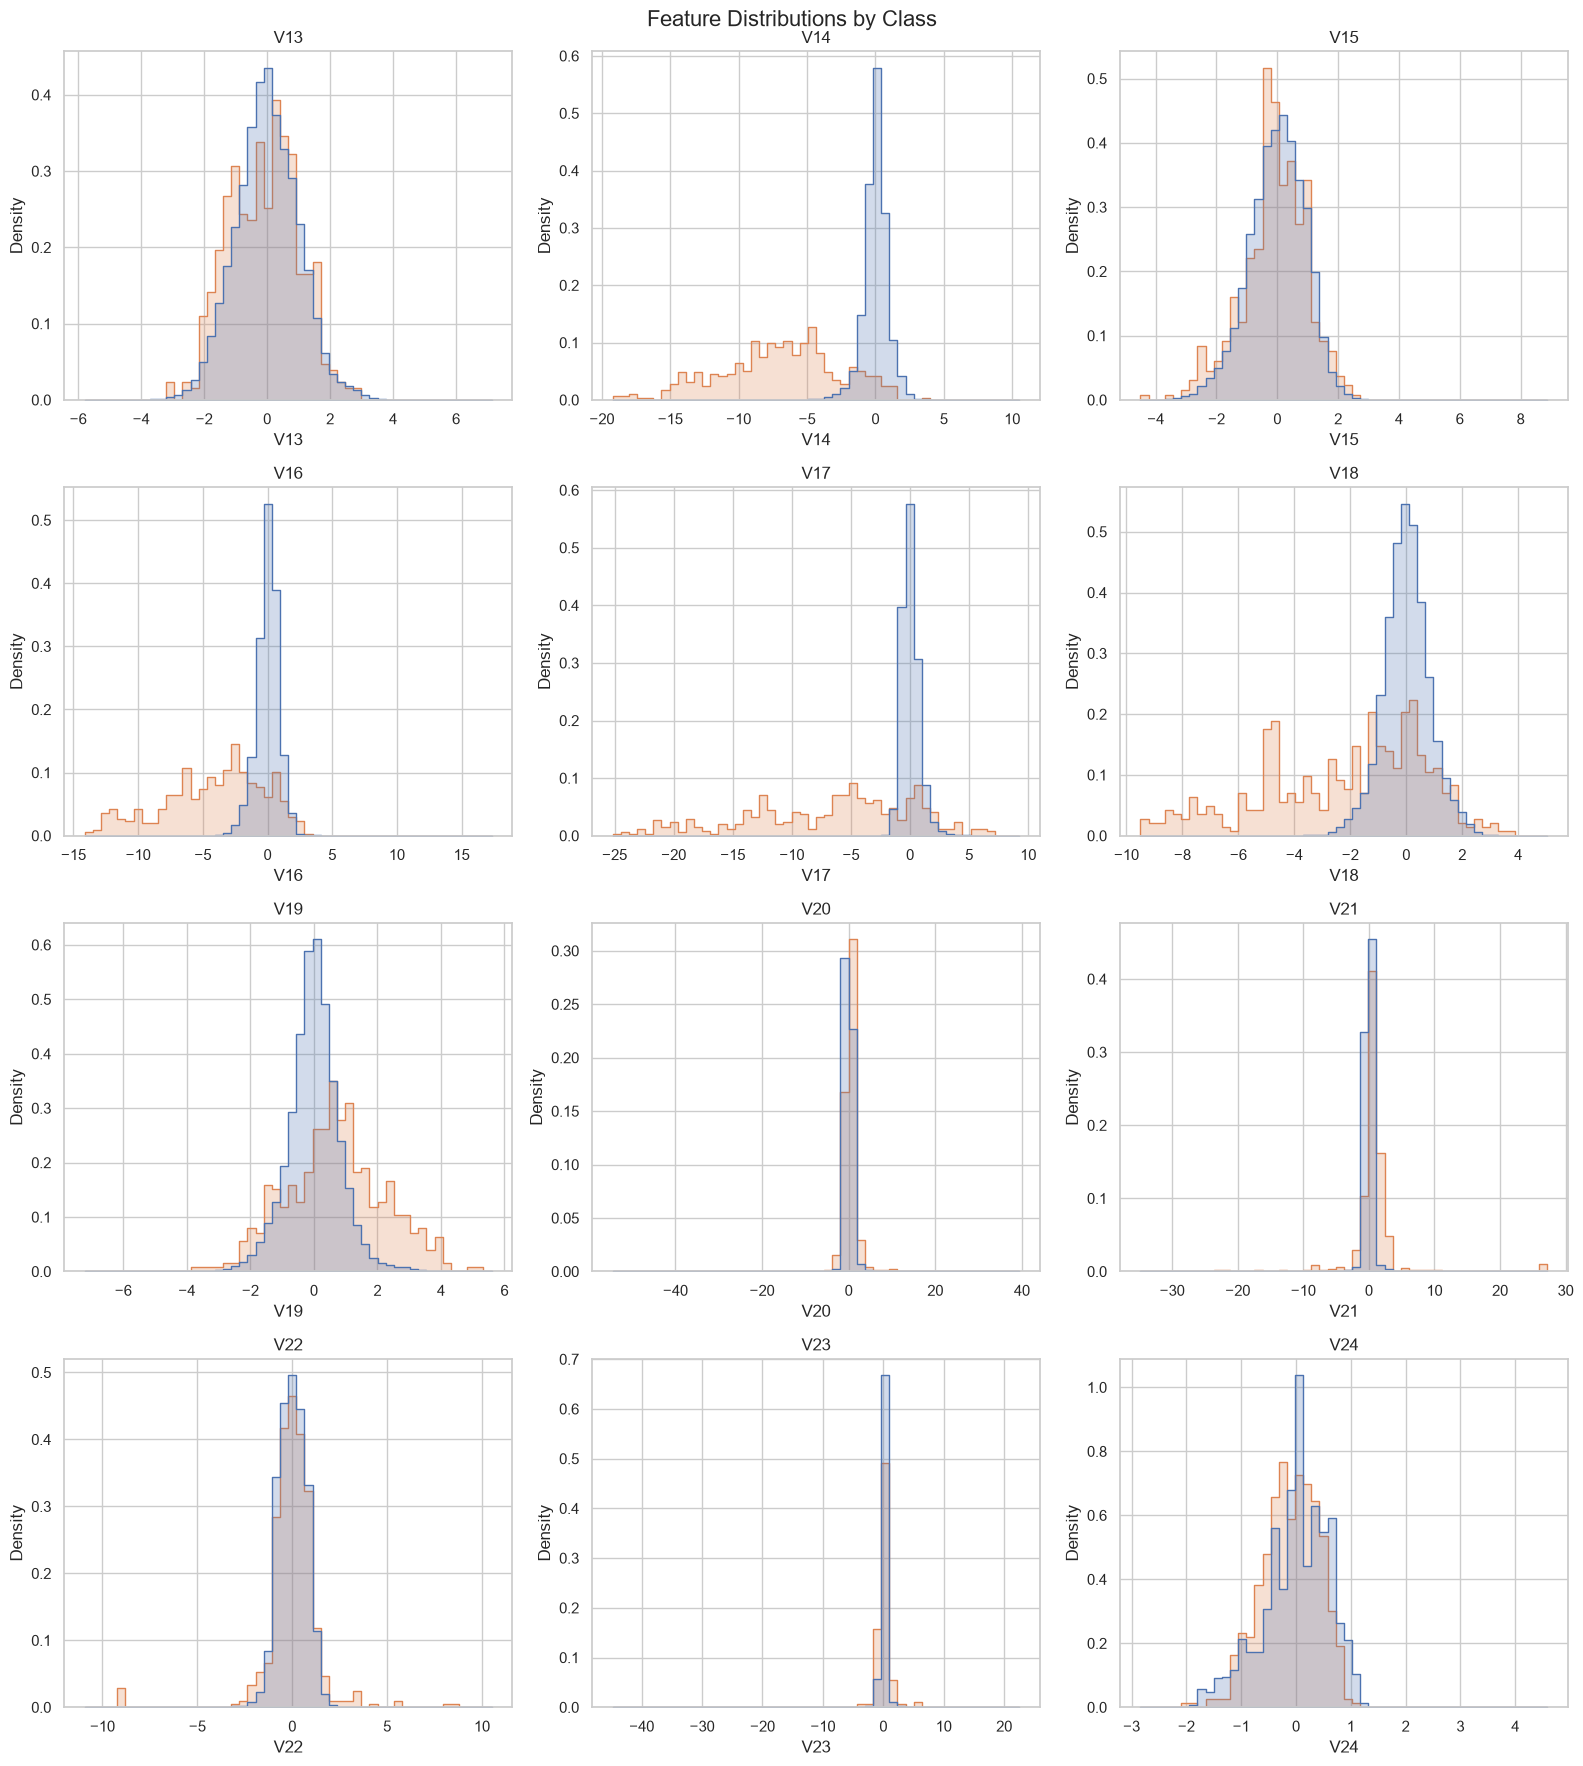

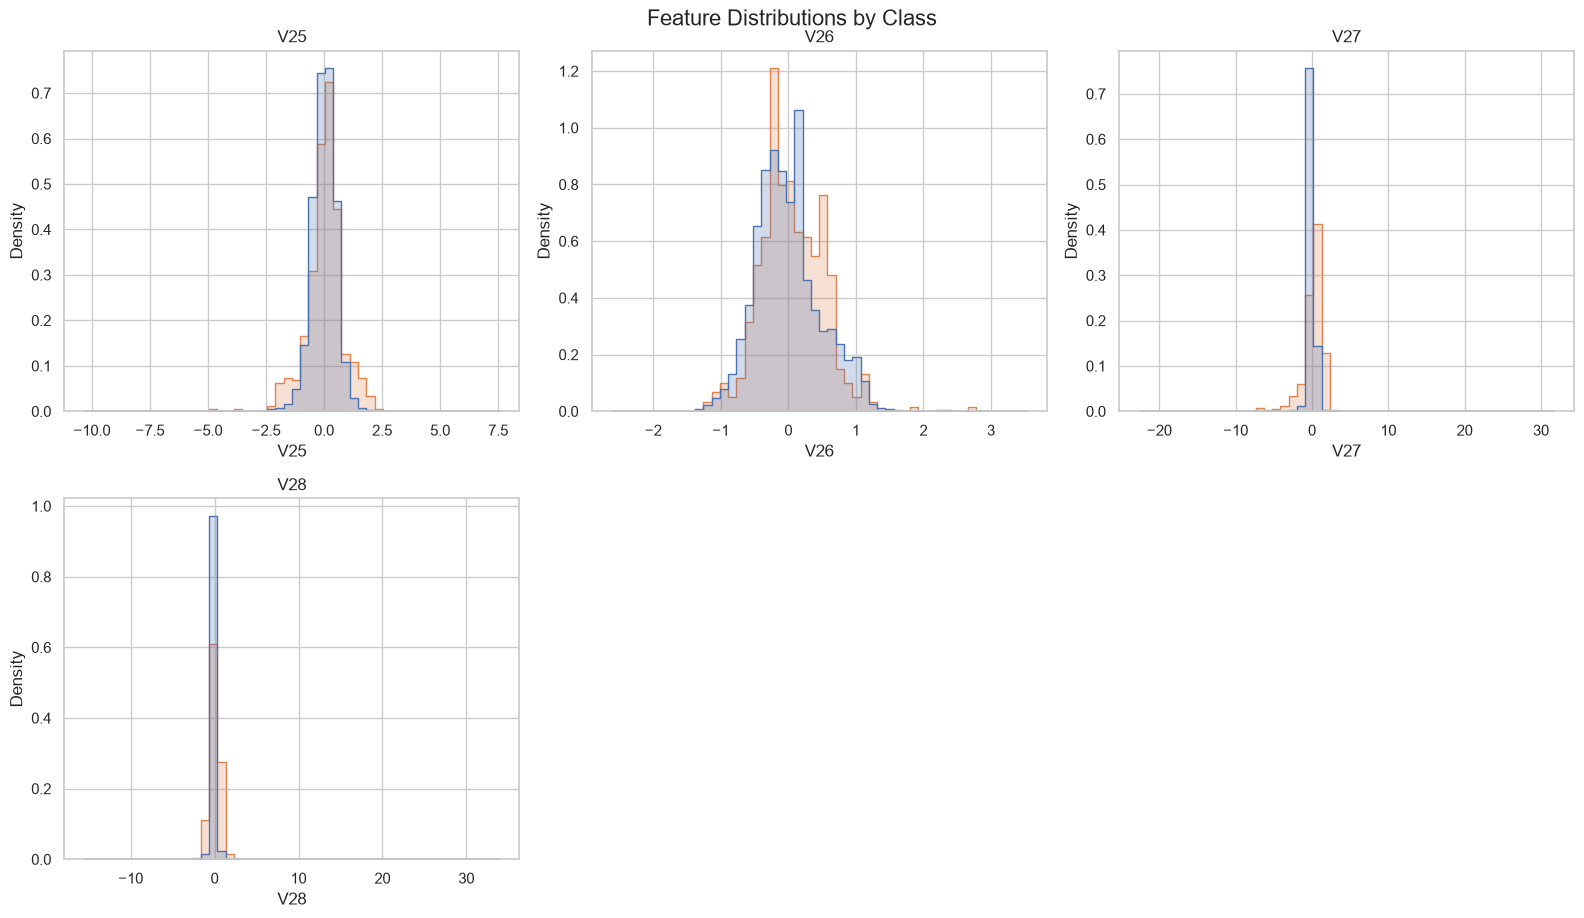

In [79]:
feature_columns = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != TARGET
]

## Standard credit-card fraud data contains anonymized V1-V28 features
features_to_plot = [
    c for c in feature_columns
    if c.startswith("V")
]

for start in range(0, len(features_to_plot), 12):
    batch = features_to_plot[start:start + 12]

    fig, axes = plt.subplots(4, 3, figsize=(16, 18))
    axes = axes.flatten()

    for ax, column in zip(axes, batch):
        sns.histplot(
            data=df,
            x=column,
            hue=TARGET,
            bins=50,
            element="step",
            stat="density",
            common_norm=False,
            legend=False,
            ax=ax,
        )
        ax.set_title(column)

    for ax in axes[len(batch):]:
        ax.set_visible(False)

    fig.suptitle("Feature Distributions by Class", fontsize=16)
    plt.tight_layout()
    plt.show()

## **8. Correlation and feature usefulness**

In [80]:
correlation = df[feature_columns + [TARGET]].corr()

target_correlation = (
    correlation[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

display(target_correlation.to_frame("correlation_with_class"))

,correlation_with_class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


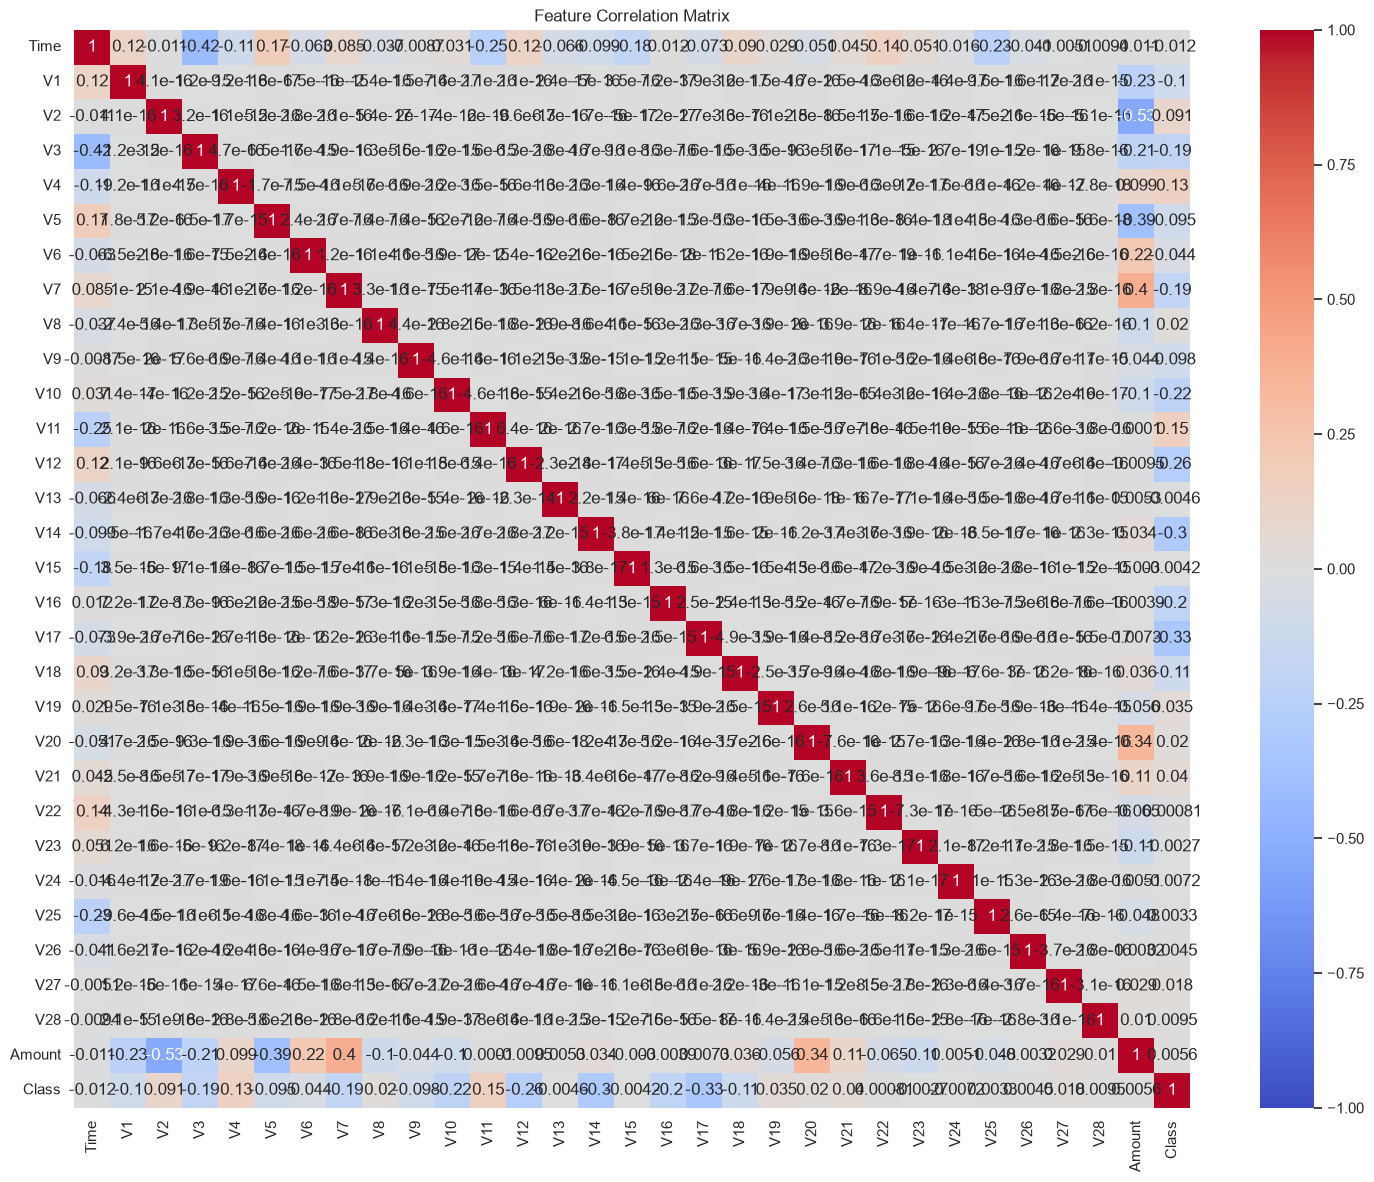

In [81]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True
)
plt.title("Feature Correlation Matrix")
plt.show()

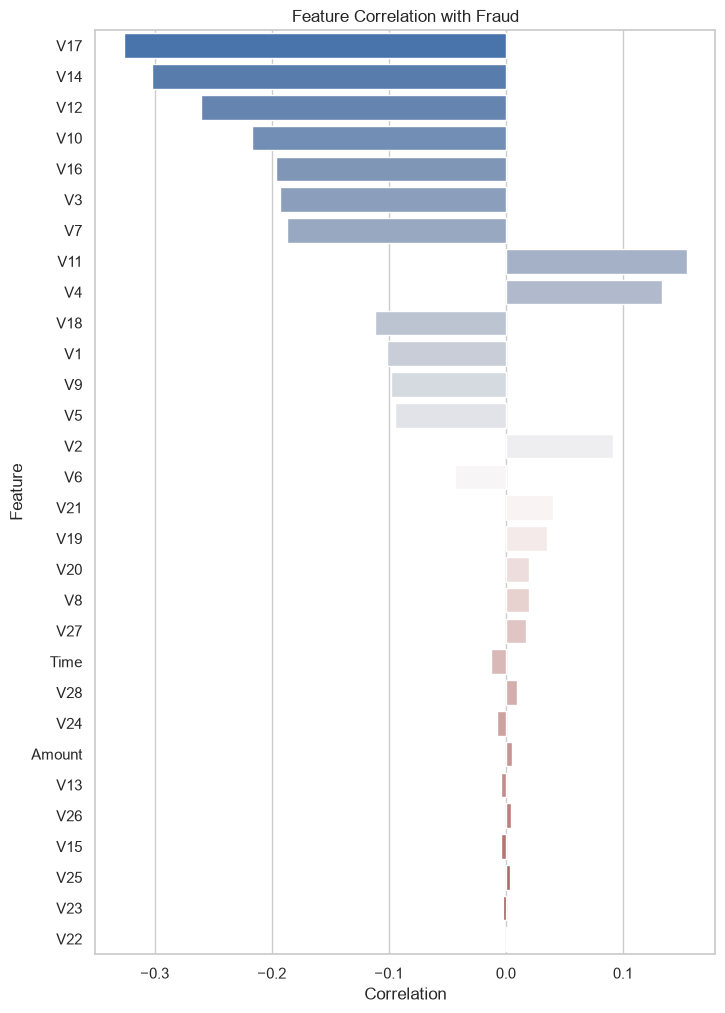

In [82]:
plt.figure(figsize=(8, 12))
sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index,
    palette="vlag",
)
plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

## **9. Class-separation statistics**

In [83]:
from sklearn.metrics import roc_auc_score

separation = []

for feature in feature_columns:
    values = df[feature].replace([np.inf, -np.inf], np.nan)

    if values.isna().all() or values.nunique() <= 1:
        continue

    auc = roc_auc_score(df[TARGET], values.fillna(values.median()))

    separation.append({
        "feature": feature,
        "single_feature_auc": max(auc, 1 - auc),
        "legitimate_median": df.loc[df[TARGET] == 0, feature].median(),
        "fraud_median": df.loc[df[TARGET] == 1, feature].median(),
        "legitimate_mean": df.loc[df[TARGET] == 0, feature].mean(),
        "fraud_mean": df.loc[df[TARGET] == 1, feature].mean(),
    })

separation = (
    pd.DataFrame(separation)
    .sort_values("single_feature_auc", ascending=False)
)

display(separation.head(20))

,feature,single_feature_auc,legitimate_median,fraud_median,legitimate_mean,fraud_mean
14,V14,0.9492,0.0519,-6.7297,0.0121,-6.9717
4,V4,0.9383,-0.0224,4.1771,-0.0079,4.5420
12,V12,0.9370,0.1417,-5.5025,0.0108,-6.2594
11,V11,0.9181,-0.0349,3.5862,-0.0066,3.8002
10,V10,0.9141,-0.0919,-4.5788,0.0098,-5.6769
3,V3,0.9121,0.1822,-5.0753,0.0122,-7.0333
2,V2,0.8550,0.0641,2.7179,-0.0063,3.6238
16,V16,0.8471,0.0674,-3.5498,0.0072,-4.1399
9,V9,0.8441,-0.0500,-2.2088,0.0045,-2.5811
7,V7,0.8358,0.0411,-3.0344,0.0096,-5.5687


## **10. Outlier analysis**

In [84]:
outlier_results = []

for feature in feature_columns:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[feature] < lower) | (df[feature] > upper)

    outlier_results.append({
        "feature": feature,
        "outlier_count": mask.sum(),
        "outlier_percent": mask.mean() * 100,
        "lower_bound": lower,
        "upper_bound": upper,
    })

outlier_summary = (
    pd.DataFrame(outlier_results)
    .sort_values("outlier_count", ascending=False)
)

display(outlier_summary.head(20))

,feature,outlier_count,outlier_percent,lower_bound,upper_bound
27,V27,39163,13.7507,-0.3137,0.3339
29,Amount,31904,11.2020,-101.7475,184.5125
28,V28,30342,10.6535,-0.2498,0.2751
20,V20,27770,9.7505,-0.7289,0.6502
8,V8,24134,8.4738,-1.0126,1.1313
6,V6,22965,8.0634,-2.5186,2.1489
23,V23,18541,6.5100,-0.6261,0.6119
12,V12,15348,5.3889,-1.9413,2.1540
21,V21,14497,5.0901,-0.8506,0.8085
14,V14,14149,4.9679,-1.8037,1.8712


## **11. Check for data leakage and unsuitable columns**

In [85]:
print("Potential identifier columns:")
for column in df.columns:
    if df[column].nunique() == len(df):
        print(f"- {column}")

print("\nPotential constant columns:")
for column in df.columns:
    if df[column].nunique() <= 1:
        print(f"- {column}")

print("\nColumns highly correlated with target:")
display(
    target_correlation[abs(target_correlation) >= 0.10]
    .to_frame("correlation_with_class")
)

Potential identifier columns:

Potential constant columns:

Columns highly correlated with target:


,correlation_with_class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115
